In [40]:
!pip install xgboost imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE

import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#load dataframe
df=pd.read_csv("feature_engineered.csv")
df.head()

,DateTime,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,...,Receiver_Tx_Count,Receiver_Mean_Amount,Hour_Tx_Volume,Time_Since_Last_Tx,unique_receivers_per_sender,unique_senders_per_receiver,sender_country_risk,receiver_country_risk,global_transactions_last_1_hour,sender_transactions_last_1_hour
0,2022-10-07 10:35:20,10:35:20,2022-10-07,1491989064,8401255335,6019.64,10,1,16,15,...,12,6021.031667,524766.5557,0.0,3,1,0.002677,0.002237,1.0,1.0
1,2022-10-07 10:35:37,10:35:37,2022-10-07,7017008854,3714297114,1971.15,10,2,16,12,...,3,1882.790000,524766.5557,0.0,2,1,0.002677,0.001891,2.0,1.0
2,2022-10-07 10:35:38,10:35:38,2022-10-07,2047410771,6646502650,8110.72,10,2,16,2,...,167,10644.205928,524766.5557,0.0,1,18,0.002677,0.002751,3.0,1.0
3,2022-10-07 10:35:43,10:35:43,2022-10-07,4473647189,7892884492,11957.87,10,11,16,17,...,108,11712.785463,524766.5557,0.0,1,13,0.002677,0.000997,4.0,1.0
4,2022-10-07 10:36:05,10:36:05,2022-10-07,1203252958,8500212178,2438.30,10,4,16,7,...,3,2120.536667,524766.5557,0.0,1,1,0.002677,0.002006,5.0,1.0


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101322 entries, 0 to 101321
Data columns (total 35 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   DateTime                         101322 non-null  object 
 1   Time                             101322 non-null  object 
 2   Date                             101322 non-null  object 
 3   Sender_account                   101322 non-null  int64  
 4   Receiver_account                 101322 non-null  int64  
 5   Amount                           101322 non-null  float64
 6   Payment_currency                 101322 non-null  int64  
 7   Received_currency                101322 non-null  int64  
 8   Sender_bank_location             101322 non-null  int64  
 9   Receiver_bank_location           101322 non-null  int64  
 10  Payment_type                     101322 non-null  int64  
 11  Is_laundering                    101322 non-null  int64  
 12  La

,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type,...,Receiver_Tx_Count,Receiver_Mean_Amount,Hour_Tx_Volume,Time_Since_Last_Tx,unique_receivers_per_sender,unique_senders_per_receiver,sender_country_risk,receiver_country_risk,global_transactions_last_1_hour,sender_transactions_last_1_hour
count,1.013220e+05,1.013220e+05,101322.000000,101322.000000,101322.000000,101322.000000,101322.000000,101322.0,101322.000000,101322.000000,...,101322.000000,101322.000000,1.013220e+05,1.013220e+05,101322.000000,101322.000000,101322.000000,101322.000000,101322.000000,101322.000000
mean,5.037016e+09,5.103610e+09,9081.574978,8.294477,6.164663,13.550394,10.350210,0.0,0.002260,13.430795,...,45.669766,9081.574978,1.373516e+06,1.008294e+05,4.280048,4.108713,0.002260,0.002260,147.860386,2.559227
std,2.916954e+09,2.893470e+09,7598.527727,3.207461,3.846381,4.527181,5.558841,0.0,0.047487,2.900125,...,73.202768,6947.789919,4.464673e+05,3.072239e+05,5.655220,6.083040,0.000761,0.001588,47.506767,3.292124
min,1.021972e+06,2.793990e+05,118.535700,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,1.000000,118.535700,8.907131e+04,0.000000e+00,1.000000,1.000000,0.000000,0.000481,1.000000,1.000000
25%,2.472611e+09,2.545024e+09,4765.860000,8.000000,2.000000,13.000000,6.000000,0.0,0.000000,11.000000,...,4.000000,4946.330000,1.208580e+06,3.440000e+02,1.000000,1.000000,0.001732,0.001270,132.000000,1.000000
50%,5.004849e+09,5.141977e+09,7436.430000,10.000000,6.000000,16.000000,11.000000,0.0,0.000000,12.000000,...,13.000000,8579.913077,1.453302e+06,2.560000e+03,2.000000,1.000000,0.002677,0.001491,156.000000,1.000000
75%,7.587963e+09,7.677731e+09,11431.045000,10.000000,10.000000,16.000000,16.000000,0.0,0.000000,17.000000,...,24.000000,11400.719439,1.636145e+06,1.237400e+04,4.000000,2.000000,0.002677,0.002751,175.000000,2.000000
max,9.999373e+09,9.998825e+09,46363.307200,12.000000,12.000000,17.000000,17.000000,0.0,1.000000,22.000000,...,242.000000,46363.307200,2.473346e+06,3.095746e+06,27.000000,21.000000,0.003567,0.006457,276.000000,26.000000


In [5]:
df.columns

Index(['DateTime', 'Time', 'Date', 'Sender_account', 'Receiver_account',
       'Amount', 'Payment_currency', 'Received_currency',
       'Sender_bank_location', 'Receiver_bank_location', 'Payment_type',
       'Is_laundering', 'Laundering_type', 'Hour', 'Minute', 'DayOfWeek',
       'Day', 'Month', 'Is_cross_border', 'Is_cross_currency',
       'Sender_Tx_Count', 'Sender_Mean_Amount', 'Sender_Std_Amount',
       'Sender_Max_Amount', 'Amount_to_Sender_Mean', 'Receiver_Tx_Count',
       'Receiver_Mean_Amount', 'Hour_Tx_Volume', 'Time_Since_Last_Tx',
       'unique_receivers_per_sender', 'unique_senders_per_receiver',
       'sender_country_risk', 'receiver_country_risk',
       'global_transactions_last_1_hour', 'sender_transactions_last_1_hour'],
      dtype='object')

In [18]:
X = df.drop(["Is_laundering","Laundering_type"], axis=1)
y = df["Is_laundering"]
groups = df["Sender_account"]

In [19]:
# Encode categorical features
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == "object":
        X[col] = le.fit_transform(X[col].astype(str))

In [8]:
#RANDOM TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state=42, stratify=y
)

In [20]:
#Group Shuffle Split
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

X_train = X_train.drop(["Sender_account","Receiver_account"], axis=1)
X_test = X_test.drop(["Sender_account","Receiver_account"], axis=1)

In [21]:
#Handling class imbalance as fraud datasets are imbalanced
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_smote).value_counts())
#SMOTE synthetically generates new fraud samples so that both classes have equal counts.

Before SMOTE: Is_laundering
0    80993
1      188
Name: count, dtype: int64
After SMOTE: Is_laundering
0    80993
1    80993
Name: count, dtype: int64


/Users/bhaanaveecs/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [22]:
#XGB
xgb_model = xgb.XGBClassifier(
    n_estimators = 300,
    learning_rate = 0.05,
    max_depth = 6,
    subsample = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = 1,
    random_state = 42,
    eval_metric = 'logloss'
)

xgb_model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [23]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20100
           1       0.21      0.39      0.28        41

    accuracy                           1.00     20141
   macro avg       0.61      0.69      0.64     20141
weighted avg       1.00      1.00      1.00     20141



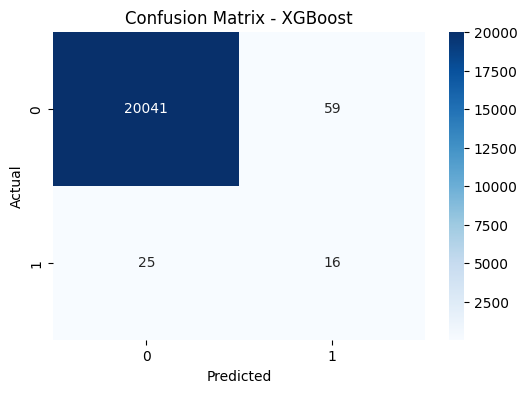

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

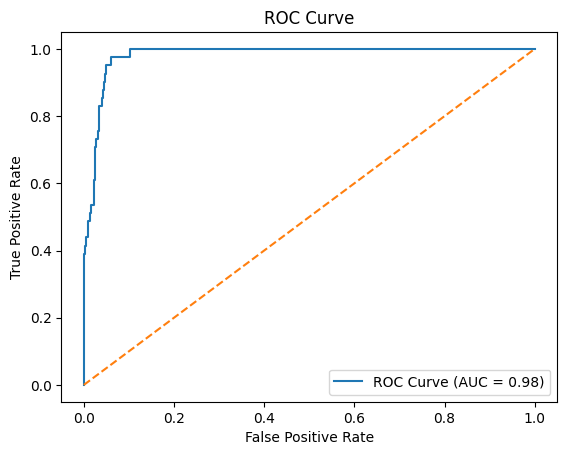

In [26]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure()

plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

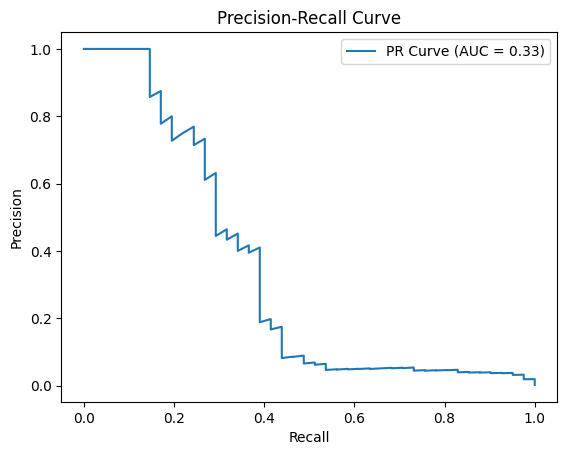

Precision-Recall AUC: 0.3341573959253891


In [27]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

pr_auc = auc(recall, precision)

plt.figure()

plt.plot(recall, precision, label="PR Curve (AUC = %0.2f)" % pr_auc)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend()
plt.show()

print("Precision-Recall AUC:", pr_auc)

<Figure size 800x600 with 0 Axes>

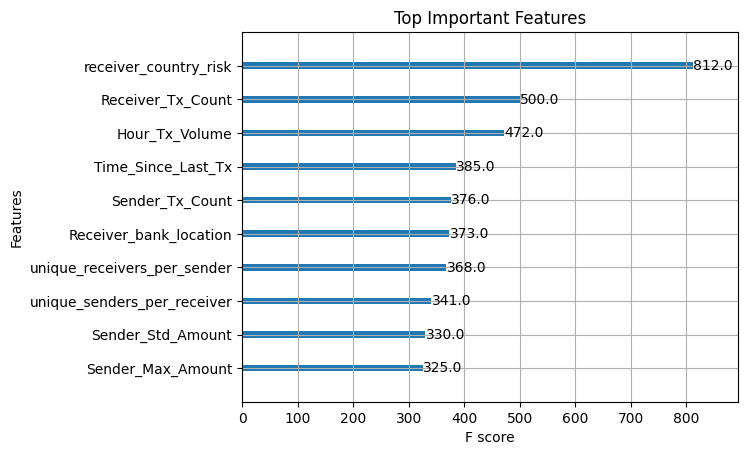

In [17]:
plt.figure(figsize=(8,6))

xgb.plot_importance(xgb_model, max_num_features=10)

plt.title("Top Important Features")
plt.show()

I finished the XGBoost part for the project. Did preprocessing, encoded categorical features, handled the class imbalance using SMOTE, trained the XGBoost model, and evaluated it using classification report, confusion matrix, ROC curve, and AUPRC. The model got an AUPRC of 0.066.
Baseline AUPRC is 46/20265=0.00227

To compare XGB and baseline 
0.066/0.00227=29.0749 so the XGB is 29 times better than a random classifier

Initially, a random train-test split produced higher fraud detection metrics. However, since sender accounts repeat in the dataset, this could introduce data leakage. Therefore, GroupShuffleSplit was used to ensure that transactions from the same sender account do not appear in both training and testing sets. This resulted in slightly lower but more realistic model performance.